<a href="https://colab.research.google.com/github/Zach-Kaplan44/Econ_5200_PS1/blob/main/Problem%20Set%201/Econ_5200_PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Econ 5200 PS1 — The Measurement Audit

**Starter notebook.** The Canvas assignment is the brief: read it first. This
notebook gives you the structure, one heading per step in the order the rubric
grades them, and the module skeleton the brief asks for. Every result is yours
to compute.

**Before you start**
1. *File › Save a copy in Drive*, and rename the copy `Econ 5200 PS1`.
2. Every claim gets a text cell. A deliverable that cannot be read without
   running it is not a deliverable.
3. **AI is not allowed in Phases 1–3.** Phase 4 requires it, with the
   transcript in `ai-appendix.md` in your repository.

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)     # one generator, so every draw is reproducible

---
## Phase 1: Reproduce the Wrong Number (15 pts)

### Step 1.1: Build the transaction data

> ### A tool you have not used yet — drawing skewed data
>
> `rng.lognormal(mean, sigma, size)` draws right-skewed positive values: most
> are modest, a few are large. `mean` and `sigma` describe the logarithm of the
> values, not the values themselves, so check `np.median(...)` of a draw
> before you settle on them. `rng.choice(...)` and `rng.integers(...)` are
> useful for the ids and the years.

At least 20,000 rows over two years: `customer_id`, `year`, `basket_value`.
Plant the B2B orders and the change in what gets logged, and record the true
consumer average for each year **before** you contaminate anything.

In [150]:
from numpy.random.mtrand import choice
# Clean consumer transactions
df_clean = pd.DataFrame({"customer_id": rng.integers(1, 1001, 20000), "basket_value": np.round(rng.lognormal(mean = np.log(50), sigma = 0.8, size = 20000), 2), "year": rng.choice([2023, 2024], 20000)})

In [151]:
# The truth: the consumer average per year, recorded before contamination
clean_mean23 = df_clean.loc[df_clean["year"]== 2023, "basket_value"].mean()
clean_mean24 = df_clean.loc[df_clean["year"]== 2024, "basket_value"].mean()

print(f"Mean before contamination 2023:  ${clean_mean23: .2f}")
print(f"Mean before contamination 2024:  ${clean_mean24: .2f}")

Mean before contamination 2023:  $ 70.11
Mean before contamination 2024:  $ 69.76


In [152]:
# Contamination 1: B2B orders
#Since B2B orders are generally large, set the mean around 5,000 and also set the customer ids
# so that they are different than the normal customer purchases.
b2b_rows = pd.DataFrame({"customer_id": rng.integers(1001, 1026, 200), "basket_value": np.round(rng.lognormal(mean = np.log(5000), sigma = 0.7, size = 200), 2), "year": rng.choice([2023, 2024], 200)})
df_b2b = pd.concat([df_clean, b2b_rows], ignore_index=True)

In [153]:
# Contamination 2: what gets logged changes between year 1 and year 2
# I used the example of cancelled orders being logged in 2024. Because they were
# cancelled, I set their basket value to $0.
log_change = pd.DataFrame({"customer_id": rng.integers(1, 1001, 500), "basket_value": 0, "year": 2024})
df_final = pd.concat([df_b2b, log_change], ignore_index=True)

### Step 1.2: Reproduce the dashboard

Compute the naive `mean(basket_value)` by year, as the dashboard does, and
quantify its gap from the truth.

In [154]:
# The dashboard's number vs the truth
naive_mean23 = df_final.loc[df_final["year"]== 2023, "basket_value"].mean()
naive_mean24 = df_final.loc[df_final["year"]== 2024, "basket_value"].mean()
mean_diff23 = naive_mean23 - clean_mean23
mean_diff24 = naive_mean24 - clean_mean24
trend_clean = clean_mean24 - clean_mean23
trend_naive = naive_mean24 - naive_mean23
pct_clean = (trend_clean/clean_mean23)*100
pct_naive = (trend_naive/naive_mean23)*100

print(f"Clean mean in 2023:  ${clean_mean23: .2f}")
print(f"Naive mean in 2023:  ${naive_mean23: .2f}")
print(f"Clean mean in 2024:  ${clean_mean24: .2f}")
print(f"Naive mean in 2024:  ${naive_mean24: .2f}")
print(f"Difference in mean between clean and naive in 2023:  ${mean_diff23: .2f}")
print(f"Difference in mean between clean and naive in 2024:  ${mean_diff24: .2f}")
print(f"Clean absolute change in mean over years:  ${trend_clean: .2f}")
print(f"Clean % change over years:  {pct_clean: .2f}%")
print(f"Naive absolute change in mean over years:  ${trend_naive: .2f}")
print(f"Naive % change in mean over years:  {pct_naive: .2f}%")
print(f"% Overstatement of mean in 2023:  {(mean_diff23/clean_mean23)*100: .2f}%")
print(f"% Overstatement of mean in 2024:  {(mean_diff24/clean_mean24)*100: .2f}%")

Clean mean in 2023:  $ 70.11
Naive mean in 2023:  $ 129.50
Clean mean in 2024:  $ 69.76
Naive mean in 2024:  $ 123.72
Difference in mean between clean and naive in 2023:  $ 59.39
Difference in mean between clean and naive in 2024:  $ 53.96
Clean absolute change in mean over years:  $-0.35
Clean % change over years:  -0.50%
Naive absolute change in mean over years:  $-5.78
Naive % change in mean over years:  -4.46%
% Overstatement of mean in 2023:   84.70%
% Overstatement of mean in 2024:   77.35%


---
## Phase 2: Locate the Cause (40 pts)

### Step 2.1: Separate the two mechanisms (25 pts)

Report each contribution as a number.

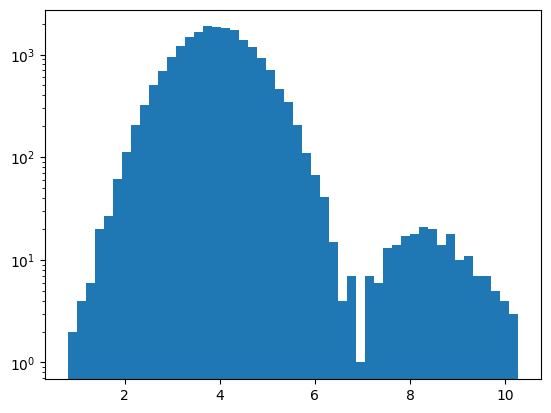

 Cutoff Threshold Candidate:  $ 1096.63
Mean in 2023 without diagnostic:  $ 129.50
Mean in 2023 with B2B sales excluded: $ 70.27
Contribution of B2B sales to overstatement of mean in 2023:  $ 59.23
Mean in 2024 without diagnostic:  $ 123.72
Mean in 2024 with B2B sales excluded: $ 66.66
Contribution of B2B sales to overstatement of mean in 2024:  $ 57.06


In [155]:
# How much of the gap is the skew and the B2B tail?
plt.hist(np.log(df_final.loc[df_final['basket_value'] > 0, "basket_value"]), bins=50, log = True)
plt.show()
print(f" Cutoff Threshold Candidate:  ${np.exp(7): .2f}")
# The histogram shows a clear gap around log 7, and then a bump after that
# which gives a clear candidate for our cutoff threshold
# The exponential of 7 gives us $1096, which I rounded up to a cleaner $1100 as the cutoff

#Skew Diagnostic
is_consumer = df_final["basket_value"] < 1100

b2bexc_mean23 = df_final.loc[(is_consumer) & (df_final["year"] == 2023), "basket_value"].mean()
b2bexc_mean24 = df_final.loc[(is_consumer) & (df_final["year"] == 2024), "basket_value"].mean()

print(f"Mean in 2023 without diagnostic:  ${naive_mean23: .2f}")
print(f"Mean in 2023 with B2B sales excluded: ${b2bexc_mean23: .2f}")
print(f"Contribution of B2B sales to overstatement of mean in 2023:  ${naive_mean23-b2bexc_mean23: .2f}")
print(f"Mean in 2024 without diagnostic:  ${naive_mean24: .2f}")
print(f"Mean in 2024 with B2B sales excluded: ${b2bexc_mean24: .2f}")
print(f"Contribution of B2B sales to overstatement of mean in 2024:  ${naive_mean24-b2bexc_mean24: .2f}")

In [156]:
# How much is the change in what was logged?
# I checked if there are values that repeat, as across 20,000 orders it is essentially
# for a price to be repeated more than a handful of times
print(df_final['basket_value'].value_counts(dropna=False).head())
# We see that there are 500 orders with $0 basket value, these are the cancelled orders
# I made a quick summary of all the orders with $0 to see if there is anything in particular about them
# such as belonging to a single customer or set of customers, or a single year
print(df_final.loc[df_final["basket_value"] == 0].describe())
# We can see that all of the cancelled orders appear in 2024
# This could indicate that either no orders were cancelled in 2023,
# or more likely that there was a difference in how orders were logged, although we know which it is

#Log Change diagnosis
completed_orders = df_final['basket_value'] > 0
# Because we know that there was a change in how orders were logged, there should be no
# change in the mean in 2023
cancelexc_mean24 = df_final.loc[(completed_orders) & (df_final["year"] == 2024), "basket_value"].mean()
cancelexc_mean23 = df_final.loc[(completed_orders) & (df_final["year"] == 2023), "basket_value"].mean()

print(f"Mean in 2024 without diagnostic:  ${naive_mean24: .2f}")
print(f"Mean in 2024 with cancelled orders excluded:  ${cancelexc_mean24: .2f}")
print(f"Contribution of cancelled sales to overstatement of mean in 2024:  ${naive_mean24 - cancelexc_mean24: .2f}")
print("Contribution of cancelled sales to overstatement of mean in 2023 is 0 as cancelled orders were not logged then" )


basket_value
0.00     500
21.76      9
36.30      8
20.72      8
13.47      8
Name: count, dtype: int64
       customer_id  basket_value    year
count   500.000000         500.0   500.0
mean    522.404000           0.0  2024.0
std     293.014949           0.0     0.0
min       3.000000           0.0  2024.0
25%     284.500000           0.0  2024.0
50%     547.500000           0.0  2024.0
75%     780.250000           0.0  2024.0
max    1000.000000           0.0  2024.0
Mean in 2024 without diagnostic:  $ 123.72
Mean in 2024 with cancelled orders excluded:  $ 129.82
Contribution of cancelled sales to overstatement of mean in 2024:  $-6.10
Contribution of cancelled sales to overstatement of mean in 2023 is 0 as cancelled orders were not logged then


| Mechanism | Contribution to the gap | How you isolated it |
|---|---|---|
| Skew and B2B tail |\$59.23 in 2023, \$57.06 in 2024 |I used a histogram of log basket values to view the distribution and see that there is a clear set of large outliers. I saw that this gap was at 7, and so taking the exponential of that, it gave us a clear cutoff around \$1,100. I used this cutoff to eliminate any values exceeding that.|
| Change in what was logged |\$0 in 2023, \$-6.10 in 2024 |I looked at the most repeated basket values to see if any values stood out as appearing implausibly often. There were 500 sales with 0 which is impossible, and by looking at the data describe I saw they were all in 2024. I isolated this by filtering for only sales where the basket value was > 0 |

### Step 2.2: Robust alternatives (15 pts)

`stats.trim_mean(x, 0.1)` drops the top and bottom 10% before averaging.

In [157]:
# Median, trimmed mean, and the mean after your B2B exclusion rule
median = df_final["basket_value"].median()
trim = stats.trim_mean(df_final['basket_value'], 0.1)
b2b_excmean = df_final.loc[(is_consumer), "basket_value"].mean()
print(f"${median}")
print(f"${trim: .2f}")
print(f"${b2b_excmean: .2f}")

$49.76
$ 57.76
$ 68.41


| Estimator | Value | The assumption that makes it right | When it would be wrong |
|---|---|---|---|
| Median |\$49.76 |That contaminated values are not near the center of the distribution |If contaminated values are prevalent enough that they reach the middle of the dataset |
| Trimmed mean |\$57.76 |That the contaminated values largely live in the top and bottom 10% of data |If the contamination is either in a different part of the top and bottom 10% of the dataset, or if the top and bottom 10% contain a large share of legitimate observations|
| Mean after B2B exclusion |\$68.41 |That the threshold used separates two distinct populations |If the excluded population and the real population have significant overlap |

**Which number should the dashboard show?** Commit to one and defend it.

It should show the mean after B2B exclusion. While the trimmed mean may seem like the correct option, due to the relatively low frequency of the 0 values, its impact on the true mean is relatively small, and removing the bottom 10% eliminates a sizable portion of the legitimate values at the bottom of the distribution.

---
## Phase 3: Ship the Fix (20 pts)

### Step 3.1: The module

The skeleton below fixes the names the brief asks for. Replace each body,
write the docstrings properly, and keep the type hints. Lab 4's
`OutlierDetector` is a model for the shape: one function per job, the method
chosen by a parameter, and no reliance on a global variable.

In [158]:
import os
os.makedirs("src", exist_ok=True)

In [159]:
%%writefile src/basket_metrics.py
"""This module ."""

import numpy as np
import pandas as pd


def audit_report(df: pd.DataFrame) -> pd.DataFrame:
    """One row per column: missingness, dtype, skew and outlier count."""
    report = []
    numeric = df.select_dtypes(include = [np.number]).columns
    for col in df:
      if col in numeric:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        report.append({"column": col,
                      "missing": df[col].isnull().sum(),
                      "dtype": df[col].dtype,
                      "skew": df[col].skew(),
                      "outlier_count": int(((df[col] < lower) | (df[col] > upper)).sum())})
    return pd.DataFrame(report)




def robust_mean(x, method: str = "median", upper: float = None, lower: float = None) -> float:
    """A robust centre for x. method: "median", "trimmed" or "trheshold" with upper and/or lower bound."""
    if method == "median":
      return np.median(x)

    elif method == "trimmed":
      return stats.trim_mean(x, 0.1)

    elif method == "threshold":
      filtered = x
      if upper is not None:
        filtered = filtered[filtered < upper]
      if lower is not None:
        filtered = filtered[filtered > lower]
      return filtered.mean()

    else:
      raise ValueError(f"Method {method} is undefined Expected median, trimmed, or threshold")



if __name__ == "__main__":
    # A short demonstration that runs when the file is run as a script
    pass

Overwriting src/basket_metrics.py


### Step 3.2: Verification checkpoint

Import the module back and test it on data it has not seen. An `assert` stops
with an error when its condition is False, which is the point: a failing
assertion tells you something.

In [160]:
import importlib
import sys
sys.path.insert(0, "src")
import basket_metrics
importlib.reload(basket_metrics)     # picks up your edits when you re-run %%writefile

df_sample = pd.DataFrame(
    {'order_value': [10, 20, 30, 40, 60, 80, 100, 130, 400],
    'units': [3, 7, 12, 5, 10, 9, 15, 3, 8],
    'delivery_eta_days': [1, 2, 2, 3, 5, 5, 7, 2, 4]}
    )
print(basket_metrics.audit_report(df_sample))
print(basket_metrics.robust_mean(df_sample['units']))
print(basket_metrics.robust_mean(df_sample['order_value']))
assert abs(basket_metrics.robust_mean(df_sample['units']) - (df_sample['units'].mean())) < 1
assert abs(basket_metrics.robust_mean(df_sample['order_value'] - (df_sample['order_value'].mean()))) > 20
assert len(basket_metrics.audit_report(df_sample)) == len(df_sample.columns)
# At least three properties that must hold, for example:
# assert abs(basket_metrics.robust_mean(symmetric_data) - symmetric_data.mean()) < tolerance

              column  missing  dtype      skew  outlier_count
0        order_value        0  int64  2.428301              1
1              units        0  int64  0.338574              0
2  delivery_eta_days        0  int64  0.632851              0
8.0
60.0


---
## Phase 4: AI Expansion (25 pts)

AI is now allowed and required. The transcript goes in `ai-appendix.md` in your
repository, linked from here: the prompt as sent, the raw reply including what
you rejected, and one line on every change you made.

**Link to `ai-appendix.md`:**

### Task 4.1: The adversarial review (15 pts)

Run the prompt from the brief, then run the strongest objection down.

**The strongest objection, and the evidence that settles it:**

In [161]:
# The analysis that settles it


med_23 = df_final.loc[(df_final['year'] == 2023), "basket_value"].median()
med_24 = df_final.loc[(df_final['year'] == 2024), "basket_value"].median()

trim_23 = stats.trim_mean(df_final.loc[(df_final['year'] == 2023), "basket_value"], 0.1)
trim_24 = stats.trim_mean(df_final.loc[(df_final['year'] == 2024), "basket_value"], 0.1)

med_trend = med_24 - med_23
trim_trend = trim_24 - trim_23
b2bexc_trend = b2bexc_mean24 - b2bexc_mean23
count_24 = (df_final['year'] == 2024).sum()
count_zero24 = ((df_final['year'] == 2024) & (df_final['basket_value'] == 0)).sum()
pct_zeros = (count_zero24/count_24) * 100

b2b_cancel_exc_mean = df_final.loc[(completed_orders) & (df_final["year"] == 2024) & (df_final['basket_value'] < 1100), "basket_value"].mean()

print(f"Change in median of revenue by year: ${med_trend: .2f}")
print(f"Change in trimmed mean of revenue by year:  ${trim_trend: .2f}")
print(f"Change in mean of revenue by year, (B2B sales excluded):  ${b2bexc_trend: .2f}")
print(f"True change in mean revenue without contaminations: ${trend_clean: .2f}")

print(f"Difference between estimated trend using contaminated median and true trend:  ${trend_clean - med_trend: .2f}")
print(f"Difference between estimated trend using trimmed mean and true trend:  ${trend_clean - trim_trend: .2f}")
print(f"Difference between estimated trend using b2b exclusion and true trend:  ${trend_clean - b2bexc_trend: .2f}")

print(f"Number of orders in 2024: {count_24}")
print(f"Number of orders in 2024 that were cancelled orders: {count_zero24}")
print(f"Percentage of orders in 2024 that were cancelled:  {pct_zeros: .2f}%")

if pct_zeros > 10:
  print("Trimmed mean does not cut off all zero values on the bottom")
elif pct_zeros < 10:
  print("Trimmed mean cuts off some non-zero values on the bottom")
else:
  print("Trimmed mean cuts off all zero values, no non-zero values trimmed on the bottom")

print(f"Mean basket value in 2023 with b2b exclusion:  ${b2bexc_mean23: .2f}")
print(f"Mean basket value in 2024 with b2b exclusion and cancelled orders removed:  {b2b_cancel_exc_mean: .2f}")



Change in median of revenue by year: $-3.30
Change in trimmed mean of revenue by year:  $-3.75
Change in mean of revenue by year, (B2B sales excluded):  $-3.60
True change in mean revenue without contaminations: $-0.35
Difference between estimated trend using contaminated median and true trend:  $ 2.95
Difference between estimated trend using trimmed mean and true trend:  $ 3.40
Difference between estimated trend using b2b exclusion and true trend:  $ 3.25
Number of orders in 2024: 10633
Number of orders in 2024 that were cancelled orders: 500
Percentage of orders in 2024 that were cancelled:   4.70%
Trimmed mean cuts off some non-zero values on the bottom
Mean basket value in 2023 with b2b exclusion:  $ 70.27
Mean basket value in 2024 with b2b exclusion and cancelled orders removed:   69.98


**What you found, including if it changes your Phase 2 recommendation:**

Based on the AI's recommendation, I examined the change in the trend of revenue between all 3 years under each estimator. I also examined what percentage of orders in 2024 were cancelled orders, and compared it with the 10% that the trimmed mean in 2024 would cut off. The recommendation would likely change to the median, as it overstates the trend the least, however the more important thing this indicates is that no single robust estimator handles this well, as they all overstate the true mean trend by about $3. This indicates that the cancelled orders, because they are not true baskets, must be removed on definitional grounds before any robust estimator is applied.

### Task 4.2: The board slide (10 pts)

150 words at most: the headline number, the correction, the confidence, and the
one thing you would still want before betting on it.


The corrected mean basket values in 2023 and 2024 are \$70.27 and \$69.98 respectively. I am confident that all cancelled orders were removed by this, however because the B2B exclusion is from observation of the data, any true customer purchases that are significantly large would be cut off by this. The number one thing I would still want would be another column that indicates customer type. This would allow for explicitly excluding B2B sales, rather than guessing from the shape of the data.

---
### Before you submit
- [ ] Truth recorded before contamination, and both mechanisms reported as numbers
- [ ] `src/basket_metrics.py` pushed with the notebook, and at least three assertions passing
- [ ] `ai-appendix.md` in the repository and linked above
- [ ] *Runtime › Restart and run all* runs without errors